# Week 0, Tutorial 2: Respiratory Rate (RR) Data Cleaning

**Authors**: Tyler Baksh, Kaylah Leigertwood-Ollivierre, Mya Symister, Sariana Ramoutar, Zhanna McDonald, Sekou Ruddock

This notebook focuses on cleaning respiratory rate (RR) data from a medical dataset. It involves converting data types, handling missing values, filtering out clinically implausible values, and imputing missing data using the median. Visualisations are used to understand the data distribution before and after cleaning.

### Mount Google Drive

This cell connects the Google Colab environment to your Google Drive. This is necessary to access the dataset stored in your Drive.

In [1]:
# Make the Google Drive data set accessible to Colab.

from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully.")

Mounted at /content/drive
Drive mounted successfully.


### Confirm Python Version

This cell verifies that the Python version running in the Colab environment meets the required specifications for this notebook. This ensures compatibility with the libraries and functions used.

In [2]:
# Confirm Python version >= 3.10
import sys
print(f'Python version: {sys.version}')

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


### Import Libraries

Here, we import all the essential Python libraries required for data handling, numerical operations, and data visualisation throughout the notebook. This includes `pandas` for dataframes, `numpy` for mathematical operations, and `matplotlib.pyplot` for plotting.

In [3]:
# Import necessary libraries:

import pandas as pd # data handling
import numpy as np # numerical operations (NaNs, Arrays)
import matplotlib.pyplot as plt # visualisation

print('Libraries imported successfully!')

Libraries imported successfully!


### Load Dataset

This cell loads the raw dataset into a pandas DataFrame from the specified file path in Google Drive. It then displays the shape (number of rows and columns) and the names of all columns to provide an initial overview of the data structure.

In [4]:
# Load dataset and display shape & column names
FILE_PATH = '/content/drive/MyDrive/CariSurg Documents/EmergencyTriageDataset_Reduced_Dirty.csv'
df_raw = pd.read_csv(FILE_PATH)

# Display dataset information
print('Dataset successfully loaded!')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns') #dataset size check
print(f'Columns: {list(df_raw.columns)}') #confirm structure

Dataset successfully loaded!
Shape: 2205 rows x 11 columns
Columns: ['ID', 'Age', 'Gender', 'GCS', 'SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'Fio2']


### Respiratory Rate (RR) Data Cleaning - Step 1: Convert to Numeric

This section focuses on cleaning the 'RR' (Respiratory Rate) column. First, it defines clinically plausible minimum and maximum values for RR. The code then converts the 'RR' column to a numeric data type, coercing any non-numeric values into `NaN` (Not a Number) to facilitate further numerical processing. It also provides a quick scan of the unique raw values and the data type before conversion, and a summary after conversion.

In [5]:
# ── Respiratory Rate (RR) Cleaning ──────────────────────────────────

COLUMN = 'RR'   # RR = Respiratory Rate (breaths per minute)
VALID_MIN = 5            # clinically plausible min RR
VALID_MAX = 60          # clinically plausible max RR
# Values outside this range are likely data entry errors or outliers needing further investigation

print(f"=== Cleaning: {COLUMN} ===")
print(f"Unique values: {df_raw[COLUMN].unique()[:15]}") # quick scan of raw values
print(f"Dtype: {df_raw[COLUMN].dtype}") # check data type
print()

# Step 1: Convert to numeric
df_raw[COLUMN] = pd.to_numeric(df_raw[COLUMN], errors='coerce') # force numberic, invalid -> NaN

# Kept as float because imputation (mean/median) produces decimals and preserves consistency
print(f"After type conversion — NaNs: {df_raw[COLUMN].isnull().sum()}")
print(df_raw[COLUMN].describe()) # summary stats after conversion

=== Cleaning: RR ===
Unique values: [14. 16. 18. 12. 19. 20. 25. 15. 24. nan 30. 29. 40. 26. 38.]
Dtype: float64

After type conversion — NaNs: 22
count    2183.000000
mean       20.262254
std         5.742333
min        12.000000
25%        17.000000
50%        18.000000
75%        21.000000
max        50.000000
Name: RR, dtype: float64


### Visualise RR Distribution Before Cleaning

This cell generates two plots to visualise the distribution of the 'RR' data *before* any further cleaning. A histogram shows the overall frequency distribution, helping to identify typical values and potential skewness. A box plot highlights outliers and the spread of the data, providing insight into extreme values that may require attention. These plots help understand the raw data's characteristics and potential issues.

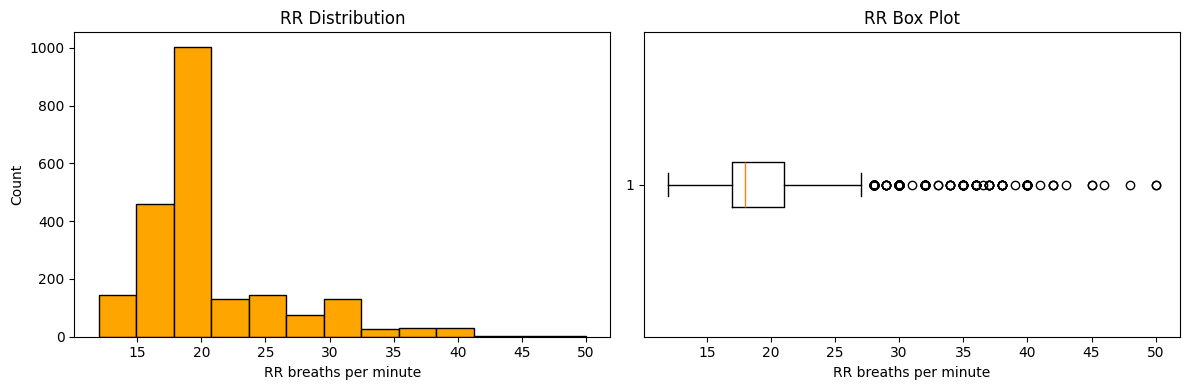

Plot saved as rr_distribution.png


In [6]:
# ── Step 1: Visualise BEFORE Cleaning ──────────────────────────────────
# This helps spot data entry errors & outliers, and visualise what a typical repiratory rate looks like for patients
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram: shows distribution
axes[0].hist(df_raw['RR'].dropna(), bins=13, edgecolor='black', color='orange') #distribution shape
axes[0].set_xlabel('RR breaths per minute')
axes[0].set_ylabel('Count')
axes[0].set_title('RR Distribution')

# Boxplot: shows outliers
axes[1].boxplot(df_raw['RR'].dropna(), vert=False) # outlier visual check
axes[1].set_xlabel('RR breaths per minute')
axes[1].set_title('RR Box Plot')

plt.tight_layout()
plt.savefig('rr_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as rr_distribution.png")

### Respiratory Rate (RR) Data Cleaning - Step 2: Range Filter & Step 3: Imputation

This section continues the cleaning of the 'RR' column.

**Step 2: Range Filtering** identifies and handles values that fall outside the clinically plausible range (defined earlier as `VALID_MIN` and `VALID_MAX`). These out-of-range values are replaced with `NaN`, treating them as missing data.

**Step 3: Imputation** addresses any remaining `NaN` values by replacing them with the *median* of the 'RR' column. The median is chosen over the mean because the data's right-skewed nature (as potentially seen in the distribution plots) makes the median a more robust and less biased imputation value. Finally, it displays summary statistics and visualisations of the 'RR' distribution *after* cleaning to confirm the data quality.

Out-of-range values: 0
Out-of-range values: 0

After cleaning:
count    2205.000000
mean       20.239683
std         5.718026
min        12.000000
25%        17.000000
50%        18.000000
75%        21.000000
max        50.000000
Name: RR, dtype: float64
NaNs remaining: 0


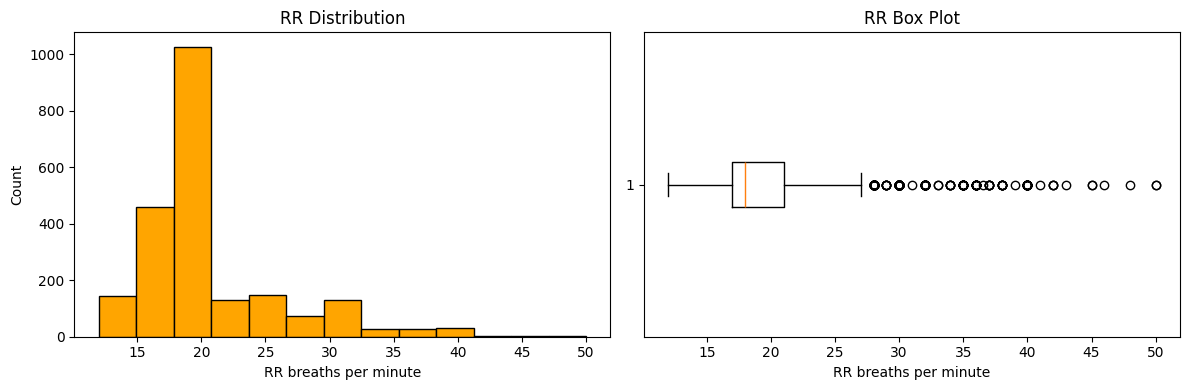

Plot saved as rr_distribution.png


In [7]:
# ── Step 2: Range filter ──────────────────────────────────
invalid = df_raw[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX)] # detect invalid clinical values
print(f"Out-of-range values: {len(invalid)}")

# note: no true outliers found (all values clinically valid ~12-50)
df_raw.loc[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX), COLUMN] = np.nan


#── Step 3: Impute ──────────────────────────────────

# median chosen because data is right-skewed (high RR values pull mean upward)
# mean (~20.24) would be biased; median (~18) is more robust

impute_value = df_raw[COLUMN].median()
(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX)
print(f"Out-of-range values: {len(invalid)}")

df_raw.loc[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX), COLUMN] = np.nan

#── Step 3: Impute ───────────────────────────────────
impute_value = df_raw[COLUMN].median()
df_raw[COLUMN] = df_raw[COLUMN].fillna(impute_value)

# Visualisation AFTER Cleaning
print(f"\nAfter cleaning:")
print(df_raw[COLUMN].describe()) # final distribution check
print(f"NaNs remaining: {df_raw[COLUMN].isnull().sum()}") # confirm no missing values left
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['RR'].dropna(), bins=13, edgecolor='black', color='orange')
axes[0].set_xlabel('RR breaths per minute')
axes[0].set_ylabel('Count')
axes[0].set_title('RR Distribution')

axes[1].boxplot(df_raw['RR'].dropna(), vert=False)
axes[1].set_xlabel('RR breaths per minute')
axes[1].set_title('RR Box Plot')

plt.tight_layout()
plt.savefig('rr_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as rr_distribution.png")
